## The Normal Equation

We generate some linear-looking data to test the normal equation

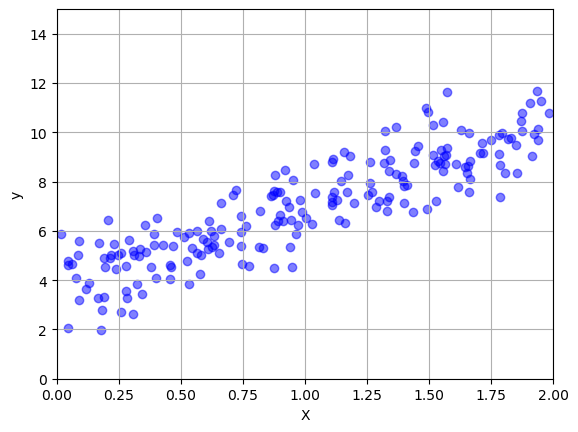

In [1]:
import numpy as np
import matplotlib.pyplot as plt

rng = np.random.default_rng(seed=42)
m = 200
X = 2 * rng.random((m,1))
y = 4 + 3 * X + rng.standard_normal((m,1))

plt.scatter(X,y,c='blue', alpha=0.5)
plt.xlabel("X")
plt.ylabel("y")
plt.xlim(0,2)
plt.ylim(0,15)
plt.grid()
plt.show()

Let's compute the predicted value $\hat{\theta}$ using the normal equation.
Note that the '@' operator performs matrix multiplication, equivalent to np.matmul()

In [2]:
from sklearn.preprocessing import add_dummy_feature

X_b = add_dummy_feature(X)
theta_best = np.linalg.inv(X_b.T @ X_b) @ X_b.T @ y

print(theta_best)

[[3.69084138]
 [3.32960458]]


In [3]:
X_new = np.array([[0],[2]])
X_new_b = add_dummy_feature(X_new)
y_predict = X_new_b @ theta_best
print(y_predict)

[[ 3.69084138]
 [10.35005055]]


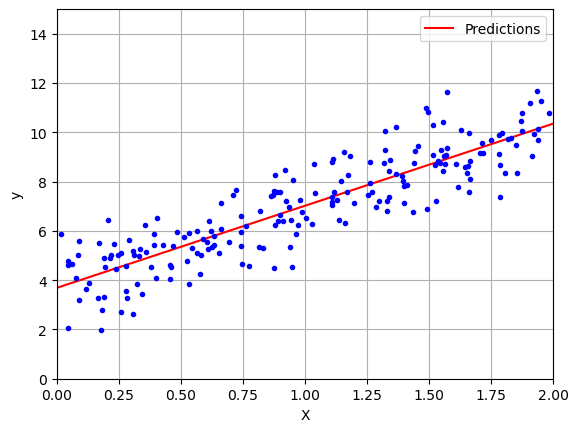

In [4]:
plt.plot(X_new, y_predict, "r-", label="Predictions")
plt.plot(X, y, "b.")
plt.xlabel("X")
plt.ylabel("y")
plt.grid('True')
plt.xlim(0,2)
plt.ylim(0,15)
plt.legend()
plt.show()

Using the Scikit-Learn, performing linear regression is much more straightforward.

In [5]:
from sklearn.linear_model import LinearRegression
lr = LinearRegression()
lr.fit(X,y)
print("The intercept is: ",lr.intercept_," and the coefficient is: ", lr.coef_)
print("The predicted value of y is: ",lr.predict(X_new))

The intercept is:  [3.69084138]  and the coefficient is:  [[3.32960458]]
The predicted value of y is:  [[ 3.69084138]
 [10.35005055]]


## Gradient Descent

In [6]:
alpha = 0.1 
n_epochs = 1000
m=len(X_b)

rng = np.random.default_rng(seed=42)
theta = rng.standard_normal((2,1))

for epoch in range(n_epochs):
    gradients = (2/m) * (X_b.T) @ (X_b @ theta - y)
    theta = theta - (alpha * gradients)

print(theta)


[[3.69084138]
 [3.32960458]]


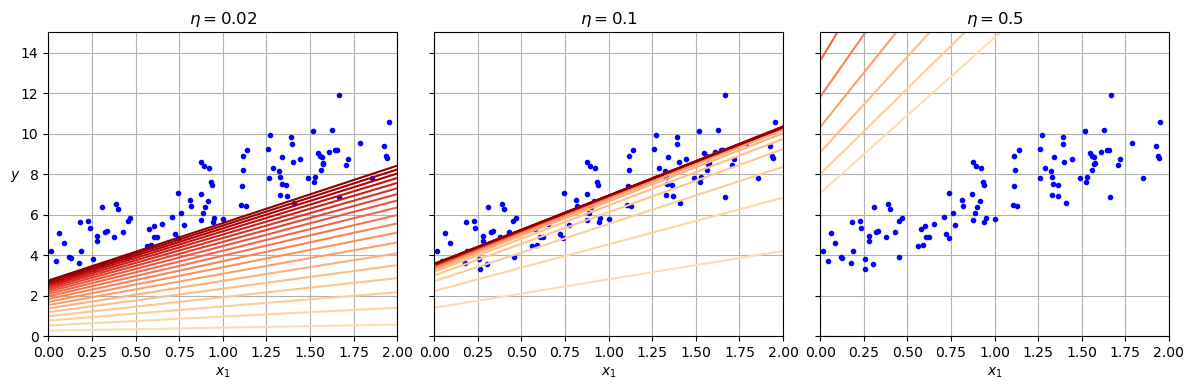

In [7]:
import numpy as np
import matplotlib as mpl
import matplotlib.pyplot as plt

# Data: y = 4 + 3x + noise 
rng = np.random.default_rng(seed=42)
m = 100
X = 2 * rng.random((m, 1))
y = 4 + 3 * X + rng.standard_normal((m, 1))

# Augment with a column of 1s so theta_0 (the bias) has a feature x0 = 1
X_b = np.c_[np.ones((m, 1)), X]

# Two endpoints are enough to draw each straight prediction line on [0, 2]
X_new   = np.array([[0], [2]])
X_new_b = np.c_[np.ones((2, 1)), X_new]


# The routine that produces one plot
def plot_gradient_descent(theta, eta, n_epochs=1000, n_shown=20):
    plt.plot(X, y, "b.")                          # scatter of the data
    for epoch in range(n_epochs):
        if epoch < n_shown:                       # only draw the first 20 lines
            y_predict = X_new_b @ theta
            shade = epoch / n_shown               
            color = mpl.colors.rgb2hex(plt.cm.OrRd(shade * 0.85 + 0.15))
            plt.plot(X_new, y_predict, color=color)
        gradients = 2 / m * X_b.T @ (X_b @ theta - y)
        theta = theta - eta * gradients           # the actual GD step
    plt.xlabel("$x_1$")
    plt.title(rf"$\eta = {eta}$")
    plt.axis([0, 2, 0, 15])
    plt.grid()
    return theta


# Call it three times, same starting point
theta_init = rng.standard_normal((2, 1))

plt.figure(figsize=(12, 4))

plt.subplot(1, 3, 1)
plot_gradient_descent(theta_init.copy(), eta=0.02)
plt.ylabel("$y$", rotation=0)

plt.subplot(1, 3, 2)
plot_gradient_descent(theta_init.copy(), eta=0.1)
plt.gca().axes.yaxis.set_ticklabels([])          # hide y-ticks on middle panel

plt.subplot(1, 3, 3)
plot_gradient_descent(theta_init.copy(), eta=0.5)
plt.gca().axes.yaxis.set_ticklabels([])          # and on the right panel

plt.tight_layout()
plt.show()